In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:\III trimester\ABA\Project\digital_wallet_ltv_dataset.csv")
df.head()
df.info()
df.describe()

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\niran\AppData\Local\Temp\ipykernel_3396\4212128032.py:1: SyntaxWarning: invalid escape sequence '\I'
  df = pd.read_csv("D:\III trimester\ABA\Project\digital_wallet_ltv_dataset.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  7000 non-null   object 
 1   Age                          7000 non-null   int64  
 2   Location                     7000 non-null   object 
 3   Income_Level                 7000 non-null   object 
 4   Total_Transactions           7000 non-null   int64  
 5   Avg_Transaction_Value        7000 non-null   float64
 6   Max_Transaction_Value        7000 non-null   float64
 7   Min_Transaction_Value        7000 non-null   float64
 8   Total_Spent                  7000 non-null   float64
 9   Active_Days                  7000 non-null   int64  
 10  Last_Transaction_Days_Ago    7000 non-null   int64  
 11  Loyalty_Points_Earned        7000 non-null   int64  
 12  Referral_Count               7000 non-null   int64  
 13  Cashback_Received 

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,CLV
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,42.633714,501.221429,9946.831439,30159.596781,2981.549969,5.002022e+06,181.934857,183.847714,2501.545429,24.837000,2496.525031,10.017571,36.528003,5.479000,5.119197e+05
std,15.516036,286.277311,5780.880822,21996.108766,2197.342208,4.390495e+06,105.102598,105.063709,1446.680026,14.560352,1440.651369,6.037067,20.389427,2.860197,4.390551e+05
min,16.000000,1.000000,10.190000,31.860000,4.620000,1.498140e+03,1.000000,1.000000,0.000000,0.000000,0.230000,0.000000,1.020000,1.000000,3.770500e+03
25%,29.000000,252.000000,4907.465000,12224.330000,1233.065000,1.363991e+06,90.000000,93.000000,1254.750000,12.000000,1269.425000,5.000000,19.130000,3.000000,1.482058e+05
50%,43.000000,506.000000,9841.170000,25469.390000,2473.185000,3.756105e+06,182.000000,184.000000,2466.000000,25.000000,2478.945000,10.000000,36.260000,5.000000,3.878180e+05
75%,56.000000,744.000000,14955.050000,44515.415000,4378.757500,7.645508e+06,273.000000,275.000000,3792.250000,37.000000,3749.375000,15.000000,54.070000,8.000000,7.748578e+05
max,69.000000,1000.000000,19996.450000,98809.240000,9917.030000,1.946773e+07,365.000000,365.000000,5000.000000,50.000000,4999.700000,20.000000,71.980000,10.000000,1.956988e+06


Data Preprocessing

In [3]:
#handling missing values
df.isnull().sum()

Customer_ID                    0
Age                            0
Location                       0
Income_Level                   0
Total_Transactions             0
Avg_Transaction_Value          0
Max_Transaction_Value          0
Min_Transaction_Value          0
Total_Spent                    0
Active_Days                    0
Last_Transaction_Days_Ago      0
Loyalty_Points_Earned          0
Referral_Count                 0
Cashback_Received              0
App_Usage_Frequency            0
Preferred_Payment_Method       0
Support_Tickets_Raised         0
Issue_Resolution_Time          0
Customer_Satisfaction_Score    0
CLV                            0
dtype: int64

Handling outliers
Since the project is based on CLV outliers must be handled carefully using log transformation method

In [4]:
#numerical features
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)

Index(['Age', 'Total_Transactions', 'Avg_Transaction_Value',
       'Max_Transaction_Value', 'Min_Transaction_Value', 'Total_Spent',
       'Active_Days', 'Last_Transaction_Days_Ago', 'Loyalty_Points_Earned',
       'Referral_Count', 'Cashback_Received', 'Support_Tickets_Raised',
       'Issue_Resolution_Time', 'Customer_Satisfaction_Score', 'CLV'],
      dtype='object')


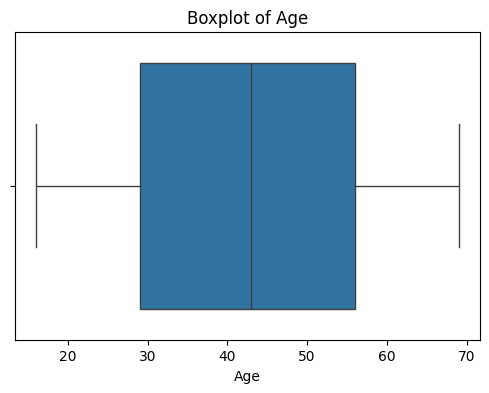

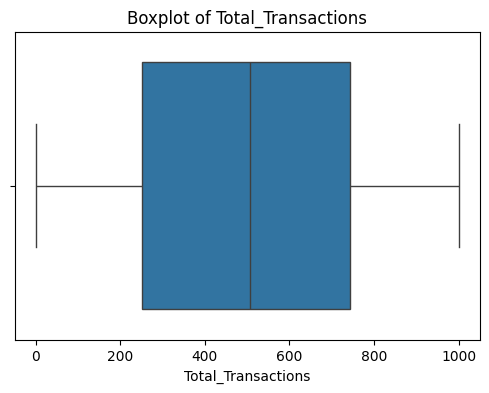

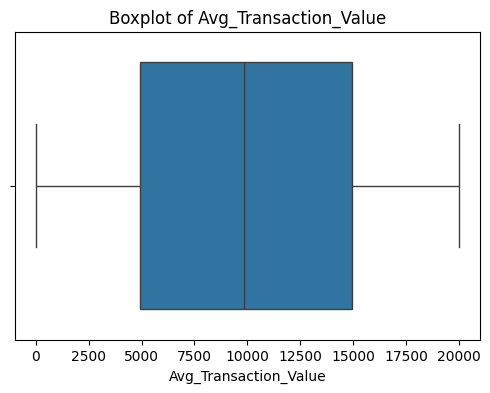

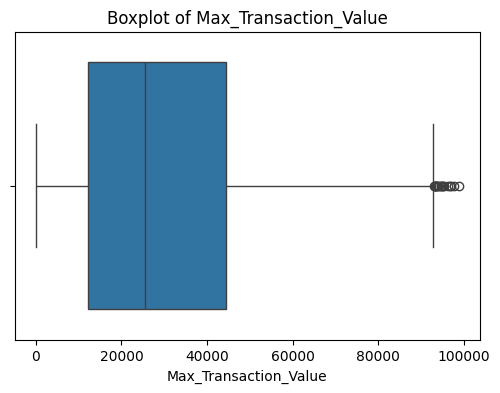

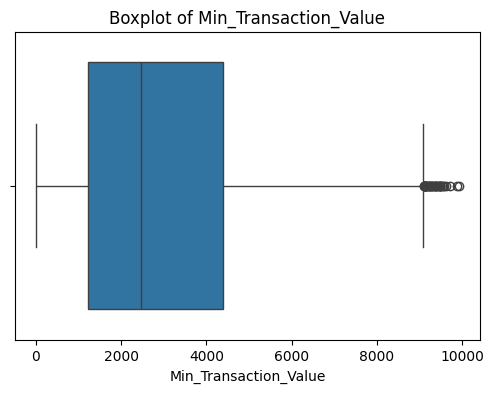

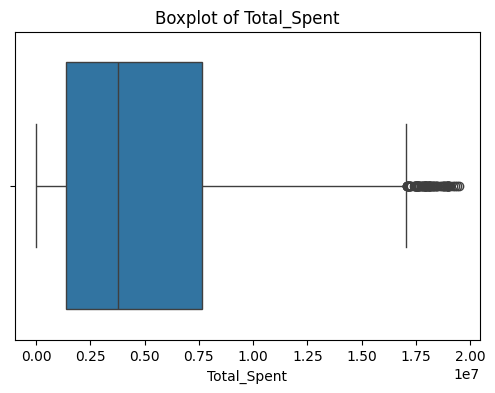

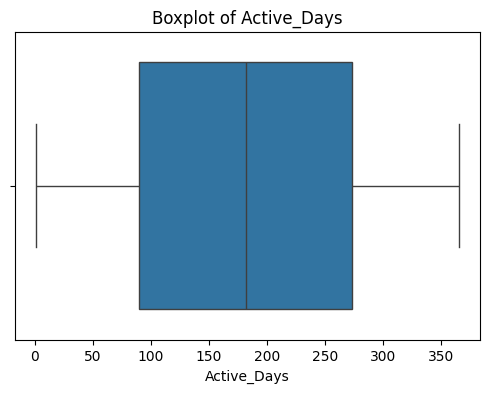

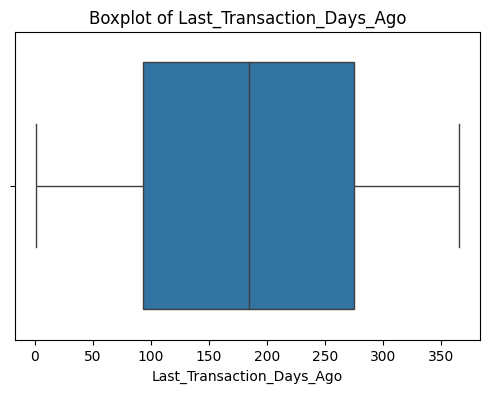

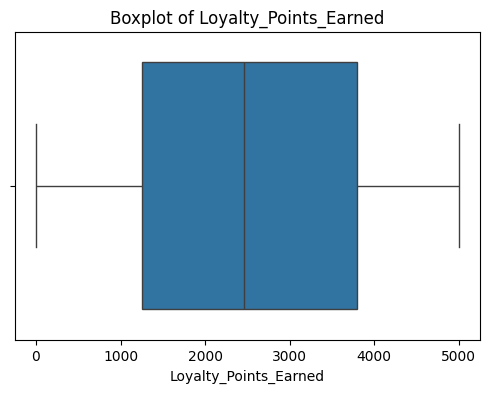

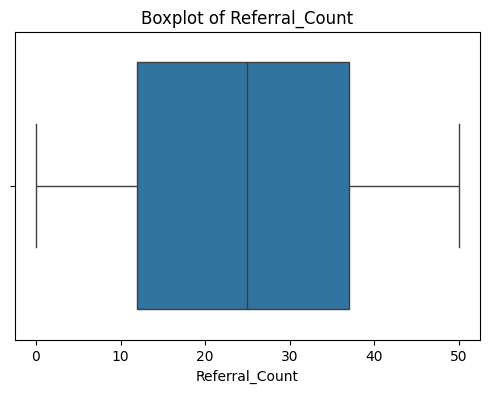

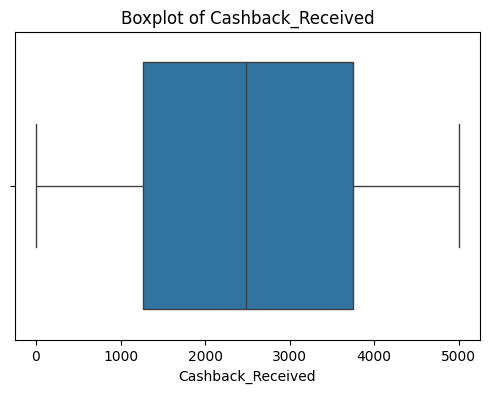

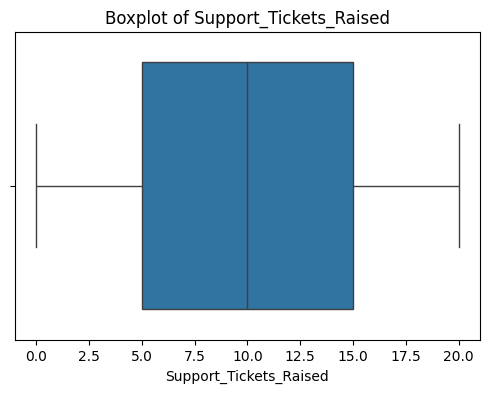

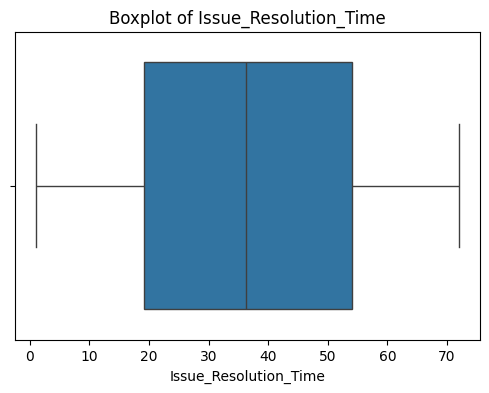

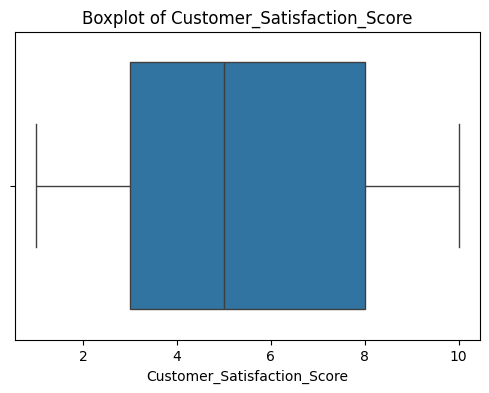

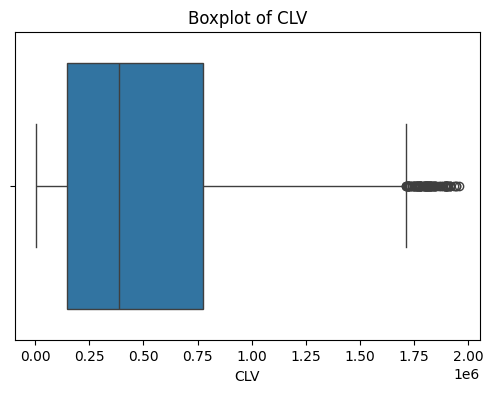

In [5]:
#Visualization of numerical features using boxplots
import matplotlib.pyplot as plt
import seaborn as sns

# your numerical columns
num_cols = ['Age', 'Total_Transactions', 'Avg_Transaction_Value',
       'Max_Transaction_Value', 'Min_Transaction_Value', 'Total_Spent',
       'Active_Days', 'Last_Transaction_Days_Ago', 'Loyalty_Points_Earned',
       'Referral_Count', 'Cashback_Received', 'Support_Tickets_Raised',
       'Issue_Resolution_Time', 'Customer_Satisfaction_Score', 'CLV']

# loop through each column
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [6]:
#Log transformation of skewed numerical features

cols_to_transform = [
    "Max_Transaction_Value",
    "Min_Transaction_Value",
    "Total_Spent",
    "CLV"
]

for col in cols_to_transform:
    df[col] = np.log1p(df[col])

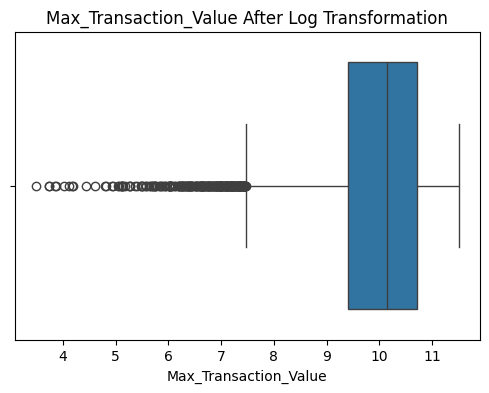

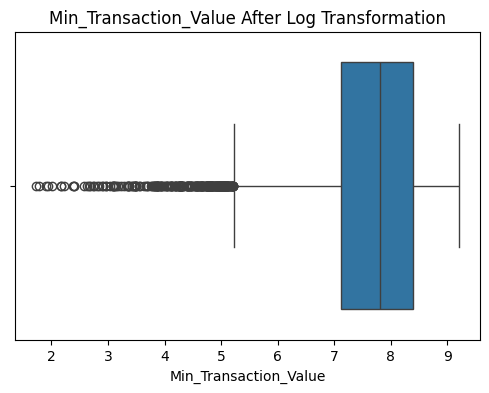

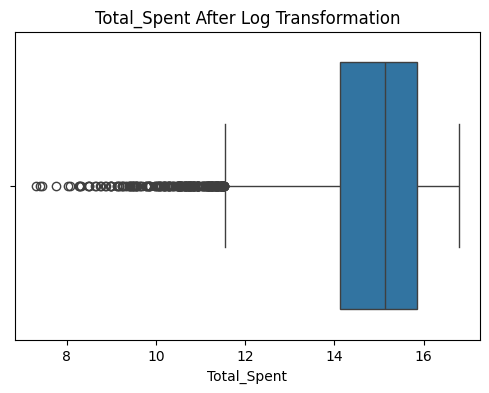

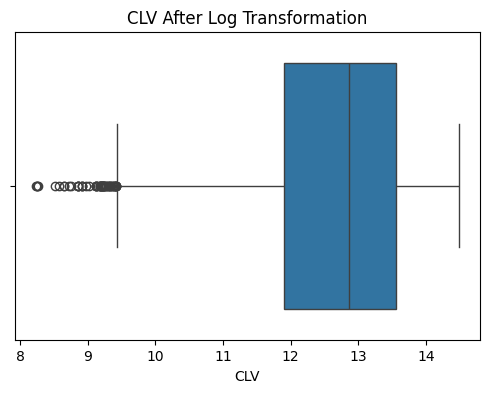

In [8]:

for col in cols_to_transform:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} After Log Transformation")
    plt.show()

In [7]:
# Check for improvement in skewness
df[cols_to_transform].skew()

Max_Transaction_Value   -1.440130
Min_Transaction_Value   -1.383377
Total_Spent             -1.336493
CLV                     -0.772164
dtype: float64

After the log transformation treatment, the outliers have been significantly reduced instead of removing it fully in order to maintain the intrgrity of the business objective

Exploratory Data Analysis

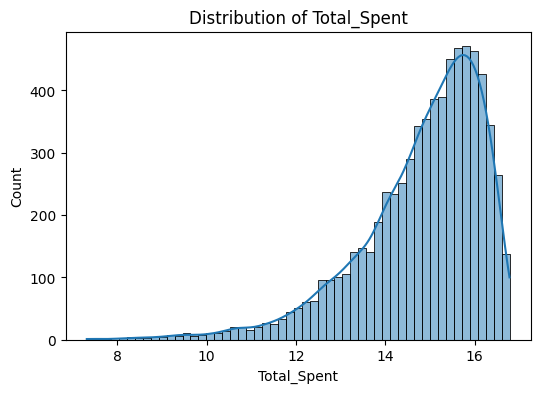

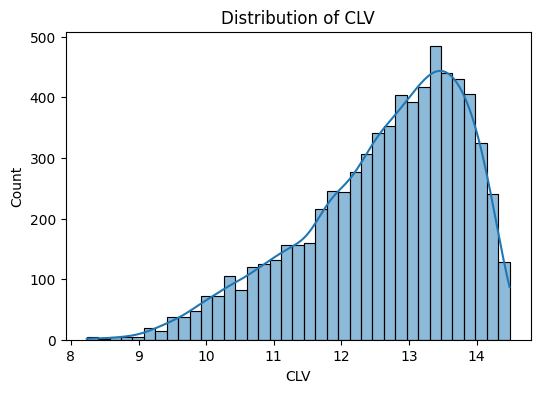

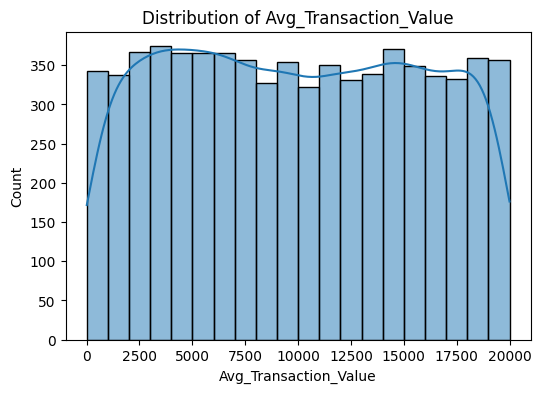

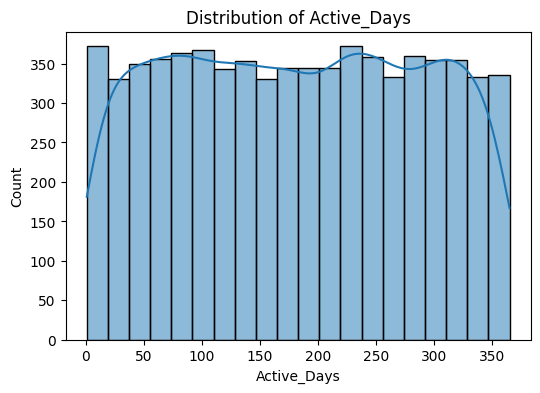

In [11]:
#univariate analysis 

for col in ['Total_Spent', 'CLV', 'Avg_Transaction_Value', 'Active_Days']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show() # the values of Total_Spent and CLV are in log transformed form in order to improve the model performance.

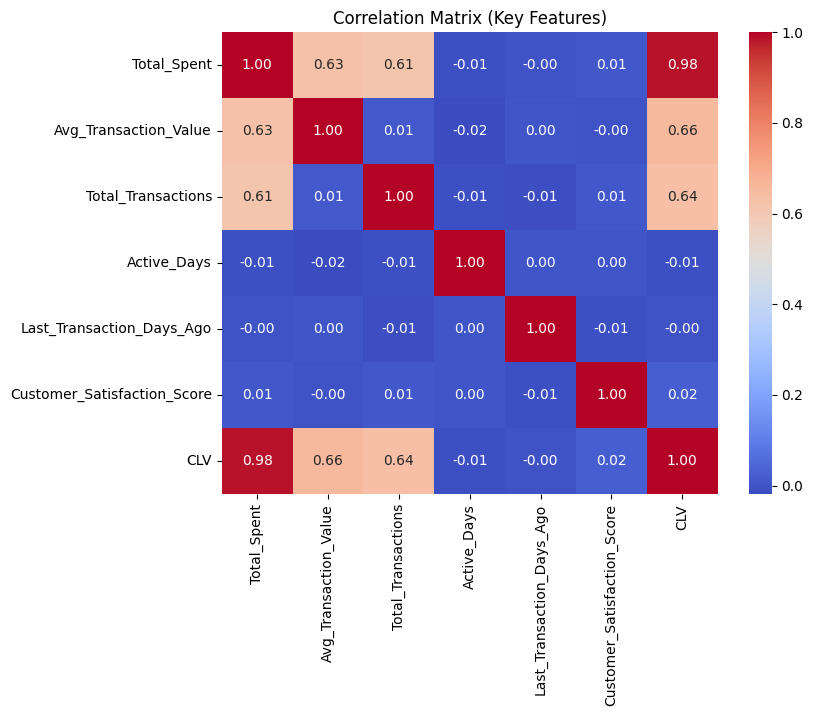

In [15]:
#correlation analysis
key_features = [
    'Total_Spent',
    'Avg_Transaction_Value',
    'Total_Transactions',
    'Active_Days',
    'Last_Transaction_Days_Ago',
    'Customer_Satisfaction_Score',
    'CLV'
]
plt.figure(figsize=(8,6))
sns.heatmap(df[key_features].corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')

plt.title("Correlation Matrix (Key Features)")
plt.show()

Location
Urban       2368
Suburban    2320
Rural       2312
Name: count, dtype: int64


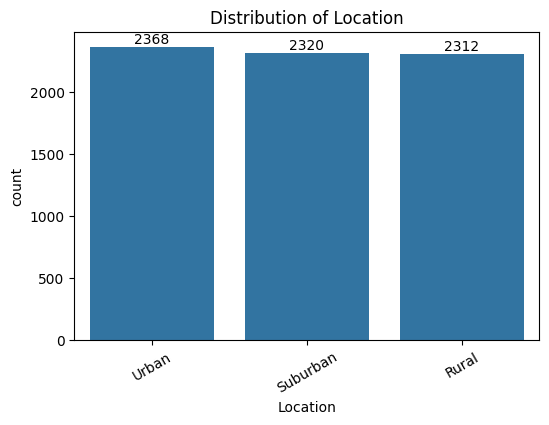

Income_Level
Middle    2391
Low       2311
High      2298
Name: count, dtype: int64


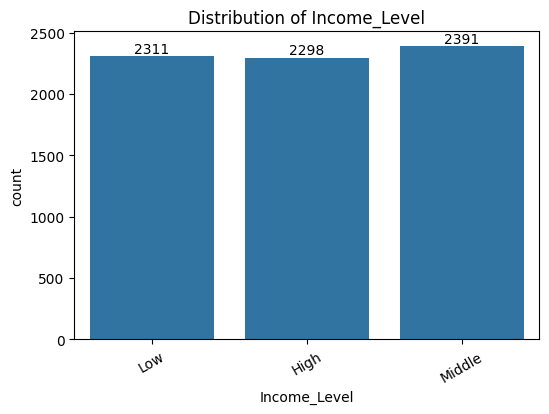

App_Usage_Frequency
Daily      2346
Monthly    2329
Weekly     2325
Name: count, dtype: int64


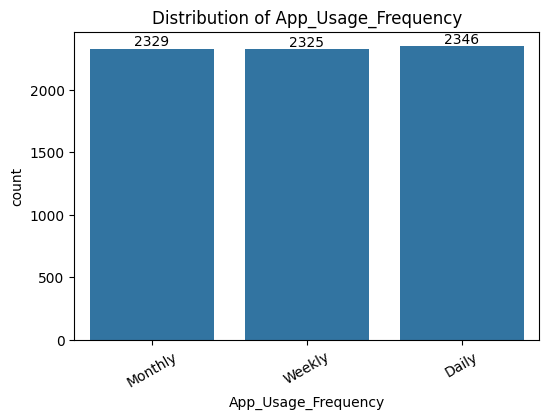

Preferred_Payment_Method
UPI               1791
Debit Card        1761
Wallet Balance    1736
Credit Card       1712
Name: count, dtype: int64


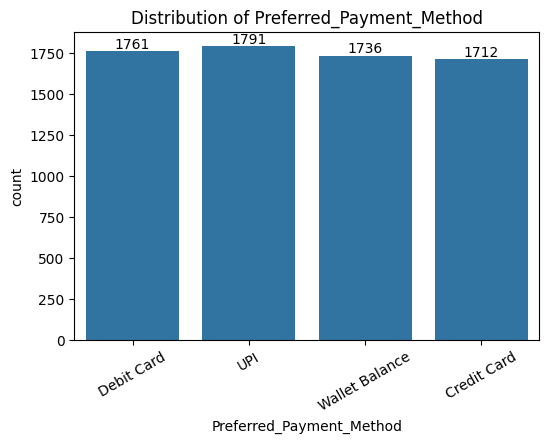

In [18]:
cat_cols = ['Location', 'Income_Level', 'App_Usage_Frequency', 'Preferred_Payment_Method']

for col in cat_cols:
    print(df[col].value_counts())

    plt.figure(figsize=(6,4))
    ax = sns.countplot(x=df[col])

    # add labels on bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom')

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.show()


Average CLV for Location:

Location
Urban       12.605948
Rural       12.635214
Suburban    12.662303
Name: CLV, dtype: float64


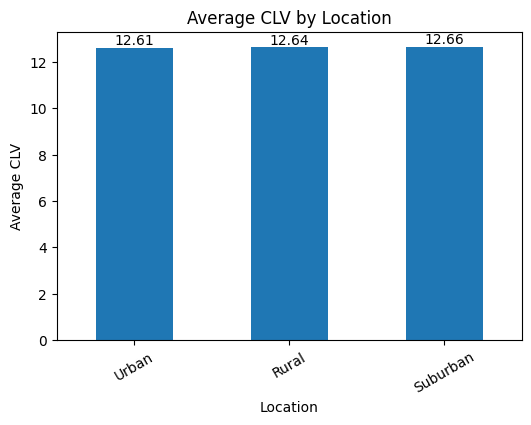


Average CLV for Income_Level:

Income_Level
High      12.613545
Low       12.643530
Middle    12.645302
Name: CLV, dtype: float64


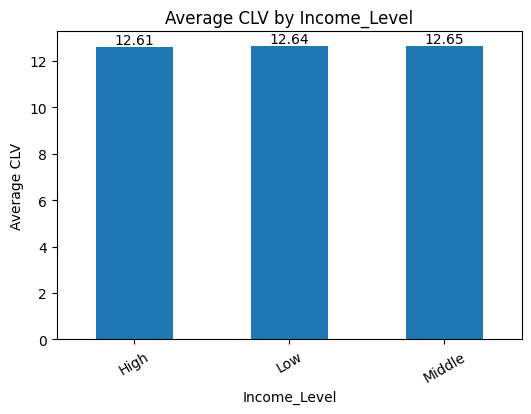


Average CLV for App_Usage_Frequency:

App_Usage_Frequency
Daily      12.619769
Weekly     12.639852
Monthly    12.643369
Name: CLV, dtype: float64


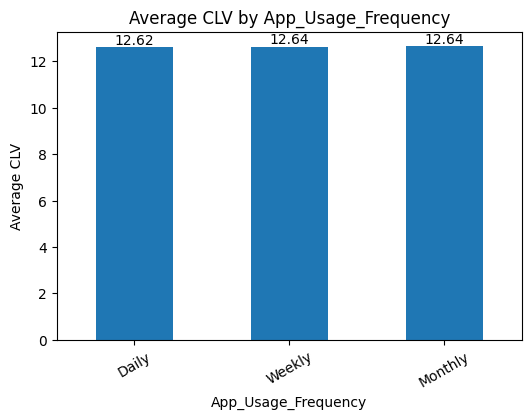


Average CLV for Preferred_Payment_Method:

Preferred_Payment_Method
Wallet Balance    12.608777
UPI               12.629031
Debit Card        12.637376
Credit Card       12.662494
Name: CLV, dtype: float64


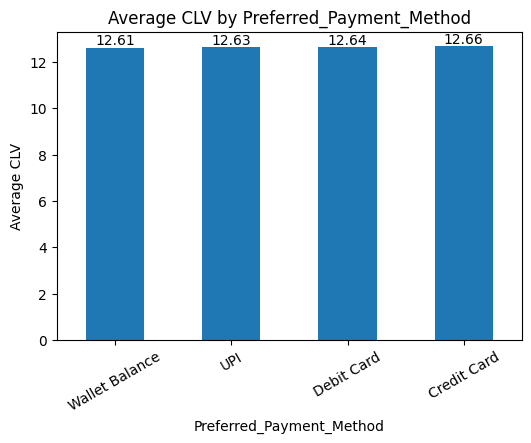

In [19]:
for col in cat_cols:
    avg_clv = df.groupby(col)['CLV'].mean().sort_values()
    
    print(f"\nAverage CLV for {col}:\n")
    print(avg_clv)

    ax = avg_clv.plot(kind='bar', figsize=(6,4))

    # add labels on bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom')

    plt.title(f"Average CLV by {col}")
    plt.ylabel("Average CLV")
    plt.xticks(rotation=30)
    plt.show()

Building Model

In [20]:
#feature selection
selected_features = [
    'Total_Spent',
    'Active_Days',
    'Last_Transaction_Days_Ago',
    'Customer_Satisfaction_Score'
]
X = df[selected_features]
y = df['CLV']

In [21]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])

# convert to dataframe
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
print(results_df)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.124239  0.049032  0.965714
1      Decision Tree  0.031894  0.006611  0.995377
2      Random Forest  0.025604  0.004705  0.996710
3  Gradient Boosting  0.027724  0.005000  0.996503
4                KNN  0.943141  1.384651  0.031769


In [31]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [32]:
df['Total_Spent'] = np.expm1(df['Total_Spent'])
df['CLV'] = np.expm1(df['CLV'])

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [34]:
# Combine training data
train_df = X_train.copy()
train_df['CLV'] = y_train

# Combine testing data
test_df = X_test.copy()
test_df['CLV'] = y_test
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

In [35]:
#training random forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
#save the model
pickle.dump(rf_model, open("clv_model.pkl", "wb"))
pickle.dump(selected_features, open("features.pkl", "wb"))

print("\nModel and feature list saved successfully!")



Model and feature list saved successfully!
